In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")

In [ ]:
data_a = np.random.normal(loc=50, scale=10, size=500)

data_b = np.random.exponential(scale=20, size=700)
data_b = data_b[data_b <= 100][:500]

data_c1 = np.random.normal(loc=30, scale=5, size=250)
data_c2 = np.random.normal(loc=70, scale=5, size=250)
data_c = np.concatenate([data_c1, data_c2])

datasets = {'Symmetric': data_a, 'Right-Skewed': data_b, 'Bimodal': data_c}
summary = {}

for name, data in datasets.items():
    summary[name] = {
        'Mean': np.mean(data),
        'Median': np.median(data),
        'Mode': stats.mode(np.round(data, 1), keepdims=True).mode[0],
        'Std Dev': np.std(data),
        'Variance': np.var(data),
        'IQR': stats.iqr(data),
        'Skewness': stats.skew(data),
        'Kurtosis': stats.kurtosis(data)
    }

summary_df = pd.DataFrame(summary).round(2)
print(summary_df)

          Symmetric  Right-Skewed  Bimodal
Mean          50.07         19.53    50.39
Median        50.13         13.96    49.27
Mode          45.30          0.40    32.80
Std Dev        9.80         18.36    20.72
Variance      96.09        337.00   429.19
IQR           13.37         22.74    39.80
Skewness       0.18          1.44    -0.01
Kurtosis       0.26          2.07    -1.77


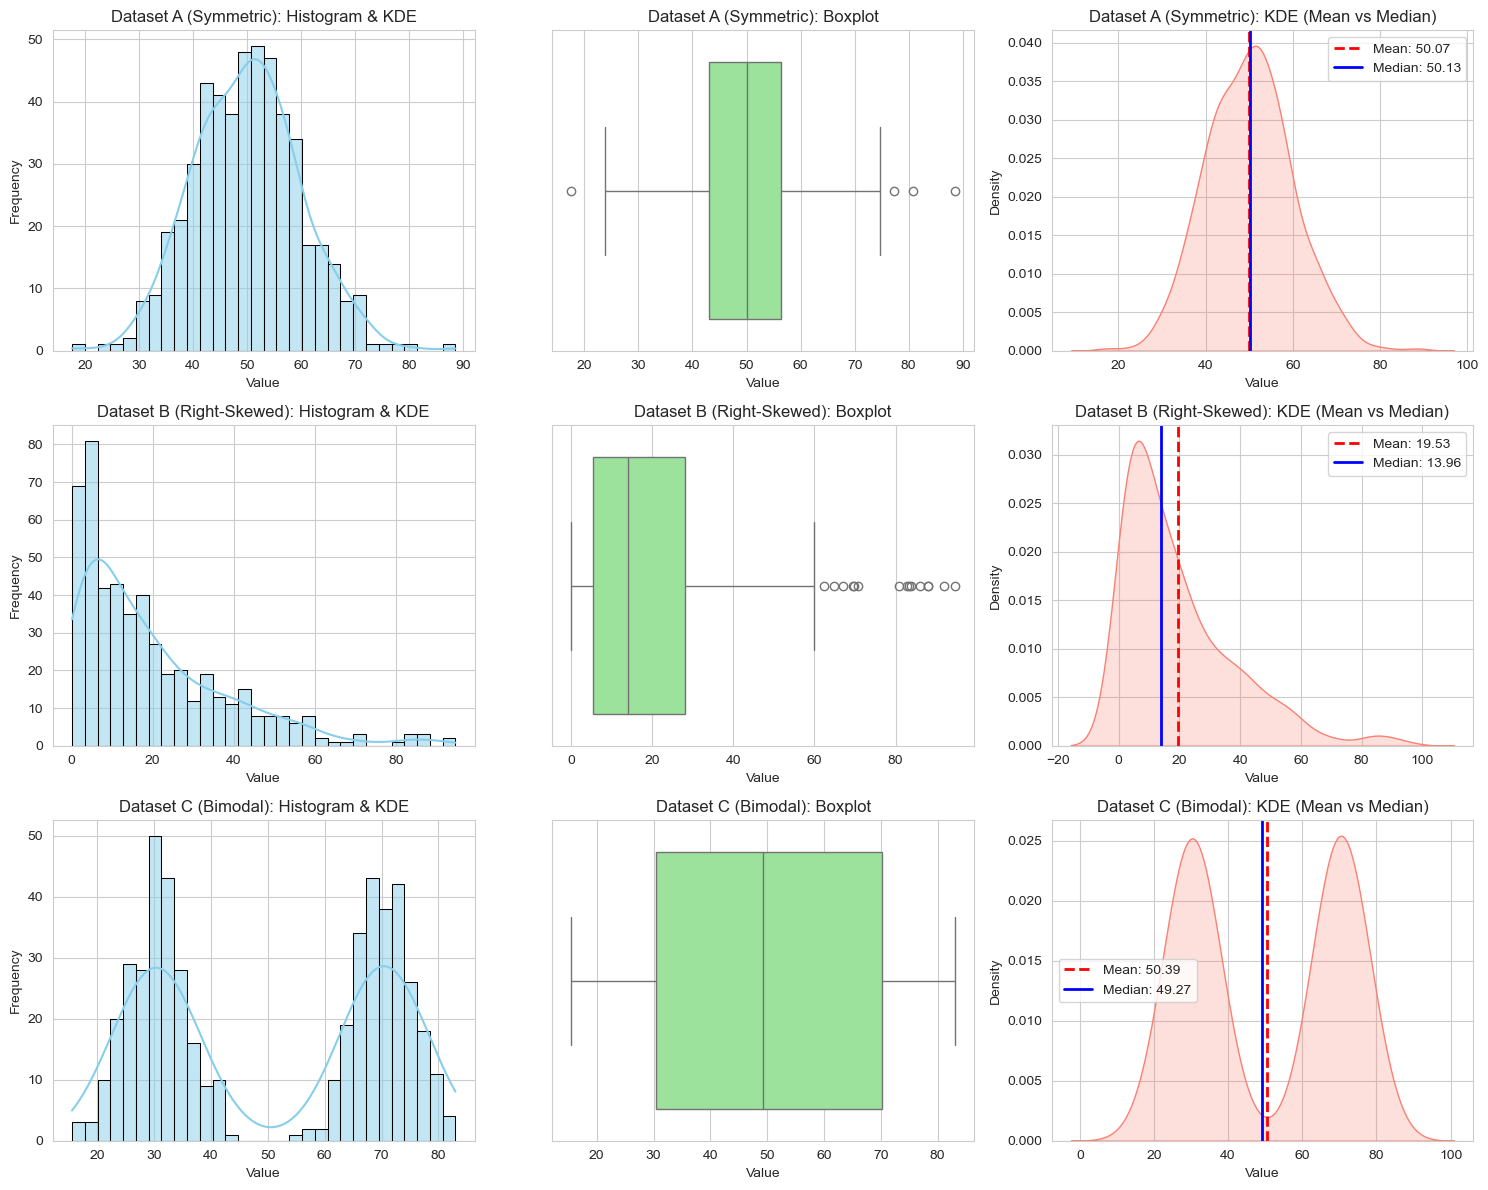

In [ ]:
datasets = [
    ('Dataset A (Symmetric)', data_a),
    ('Dataset B (Right-Skewed)', data_b),
    ('Dataset C (Bimodal)', data_c)
]


fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, (name, data) in enumerate(datasets):
    mean_val = np.mean(data)
    median_val = np.median(data)
    
    
    sns.histplot(data, bins=30, kde=True, ax=axes[i, 0], color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f'{name}: Histogram & KDE')
    axes[i, 0].set_xlabel('Value')
    axes[i, 0].set_ylabel('Frequency')
    
    sns.boxplot(x=data, ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'{name}: Boxplot')
    axes[i, 1].set_xlabel('Value')
    
    sns.kdeplot(data, ax=axes[i, 2], color='salmon', fill=True)
    axes[i, 2].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[i, 2].axvline(median_val, color='blue', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[i, 2].set_title(f'{name}: KDE (Mean vs Median)')
    axes[i, 2].set_xlabel('Value')
    axes[i, 2].set_ylabel('Density')
    axes[i, 2].legend()

plt.tight_layout()
plt.savefig('distributions_3x3.png')

          Original  Modified  Difference
Variance    100.43   5307.49     5207.06
Kurtosis     -0.01     92.71       92.72
Std Dev      10.02     72.85       62.83
Skewness      0.05      9.63        9.58
Mean         49.50     56.46        6.96
Median       49.73     49.73        0.00
Mode         41.70     41.70        0.00
IQR          13.48     13.48        0.00


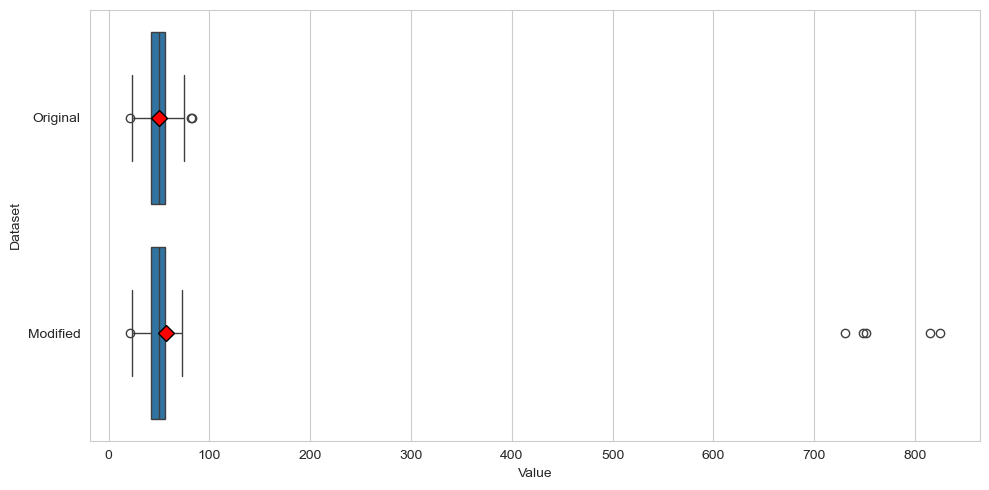

In [8]:
original_data = np.random.normal(loc=50, scale=10, size=500)

modified_data = original_data.copy()
top_5_indices = np.argpartition(modified_data, -5)[-5:]
modified_data[top_5_indices] = modified_data[top_5_indices] * 10

datasets = {'Original': original_data, 'Modified': modified_data}
summary = {}

for name, data in datasets.items():
    summary[name] = {
        'Mean': np.mean(data),
        'Median': np.median(data),
        'Mode': stats.mode(np.round(data, 1), keepdims=True).mode[0],
        'Std Dev': np.std(data),
        'Variance': np.var(data),
        'IQR': stats.iqr(data),
        'Skewness': stats.skew(data),
        'Kurtosis': stats.kurtosis(data)
    }

df = pd.DataFrame(summary).round(2)
df['Difference'] = df['Modified'] - df['Original']
df['Abs Difference'] = df['Difference'].abs()
df = df.sort_values(by='Abs Difference', ascending=False).drop(columns=['Abs Difference'])

print(df[['Original', 'Modified', 'Difference']])

plt.figure(figsize=(10, 5))
plot_data = pd.DataFrame({
    'Value': np.concatenate([original_data, modified_data]),
    'Dataset': ['Original'] * 500 + ['Modified'] * 500
})

sns.boxplot(
    data=plot_data, 
    x='Value', 
    y='Dataset', 
    showmeans=True,
    meanprops={"marker":"D", "markerfacecolor":"red", "markeredgecolor":"black", "markersize":8}
)

plt.tight_layout()
plt.show()

Looking at the printout, variance and kurtosis changed the absolute most. They shot up into the thousands. This happens because the math for those two stats multiplies distances by themselves, so a huge outlier makes the final number explode. The mean, standard deviation, and skewness also jumped up because the giant numbers pulled everything to the right.

The median, mode, and IQR were completely untouched. They stayed exactly the same. They only care about the order of the numbers, not the actual size of the biggest ones. The middle of the pack is still the middle of the pack.

If I had to pick a "typical" value for this new dataset, I would pick the median. The mean got dragged up to about 57, which makes it look like the whole group shifted higher. But in reality, 495 out of the 500 points are still sitting right around 50. The median stayed right at 50, which tells a much more honest story about where the bulk of the data actually is.